# Data Visualization Scripts

## Imports

In [50]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

## Load data

In [46]:
path = "data/"
prefix = "2026-"

target_csv_files = glob.glob(os.path.join(path, f"{prefix}*.csv"))

df_list = []
for csv_file in target_csv_files:
   df = pd.read_csv(csv_file, encoding="utf-8", on_bad_lines="skip")
   df_list.append(df)

df_all_data = pd.concat(df_list, ignore_index=True)
df_all_data.head(n=5)

,time,battery_percent,current_window,num_chrome_tabs,active_chrome_tab_url
0,2026-03-23T03:32:00-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
1,2026-03-23T05:43:56-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
2,2026-03-23T05:44:00-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
3,2026-03-23T07:46:00-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
4,2026-03-23T08:51:16-0400,95%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...


## Data cleaning

In [47]:
df_all_data["time"] = pd.to_datetime(df_all_data["time"])
df_all_data["hour"] = df_all_data["time"].dt.hour

# Filtering data to only ones between 8 AM and 6 PM
df_all_data_cleaned = df_all_data[df_all_data["time"].dt.hour.between(8, 18)]

print(
    df_all_data_cleaned["hour"].value_counts().sort_index()
    )

hour
8      13
9     219
10    268
11    249
12    138
13    197
14    214
15    255
16    218
17     29
18     24
Name: count, dtype: int64


In [ ]:
# Removing the % suffix in battery percent column
df_all_data_cleaned["battery_percent"] = (
    df_all_data_cleaned["battery_percent"].str.replace("%", "", regex=False)
    .astype(int)
)

In [56]:
df_all_data_cleaned.head(n=5)

,time,battery_percent,current_window,num_chrome_tabs,active_chrome_tab_url,hour
4,2026-03-23 08:51:16-04:00,95,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...,8
5,2026-03-23 08:52:00-04:00,95,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...,8
6,2026-03-23 08:54:00-04:00,95,Slack,27.0,https://pygithub.readthedocs.io/en/stable/apis...,8
7,2026-03-23 08:56:00-04:00,95,Slack,30.0,https://pygithub.readthedocs.io/en/stable/apis...,8
8,2026-03-23 08:58:01-04:00,94,Google Chrome,35.0,https://www.google.com/search?q=windows+list+l...,8


## Charts

<Axes: >

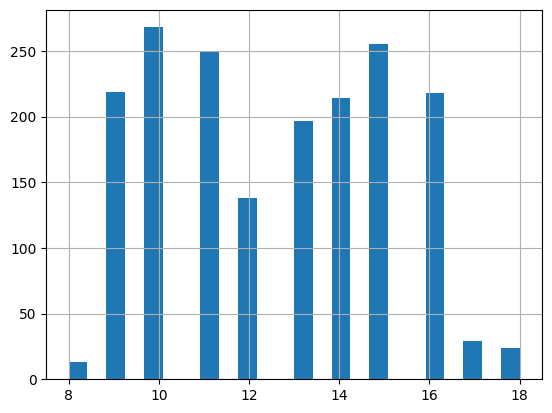

In [57]:
df_all_data_cleaned["time"].dt.hour.hist(bins=24)

<Axes: xlabel='current_window'>

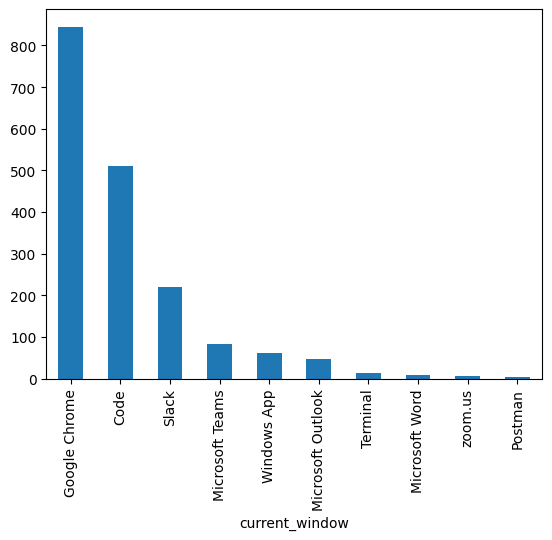

In [65]:
df_all_data_cleaned["current_window"].value_counts().head(10).plot(kind="bar")

<Axes: >

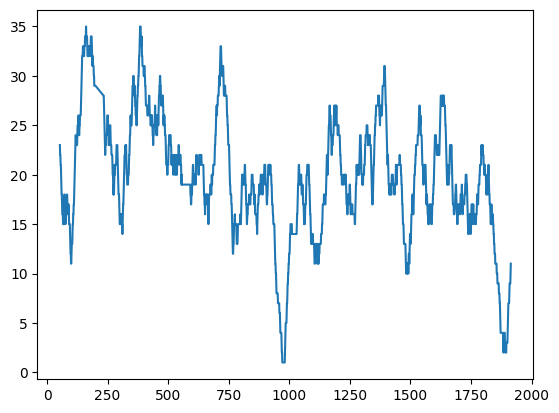

In [66]:
df_all_data_cleaned["window_change"] = df_all_data_cleaned["current_window"] != df_all_data_cleaned["current_window"].shift()
df_all_data_cleaned["window_change"].rolling(50).sum().plot()

<Axes: xlabel='domain'>

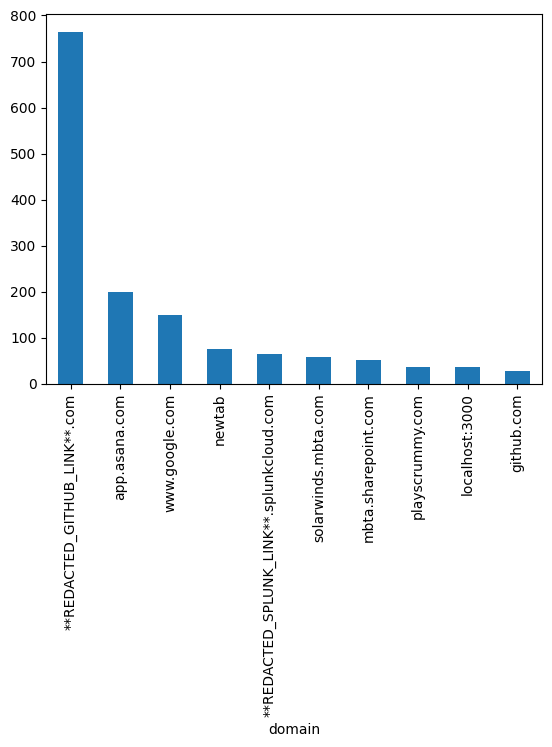

In [67]:
from urllib.parse import urlparse

df_all_data_cleaned["domain"] = df_all_data_cleaned["active_chrome_tab_url"].dropna().apply(
    lambda x: urlparse(x).netloc
)

df_all_data_cleaned["domain"].value_counts().head(10).plot(kind="bar")

<Axes: ylabel='Frequency'>

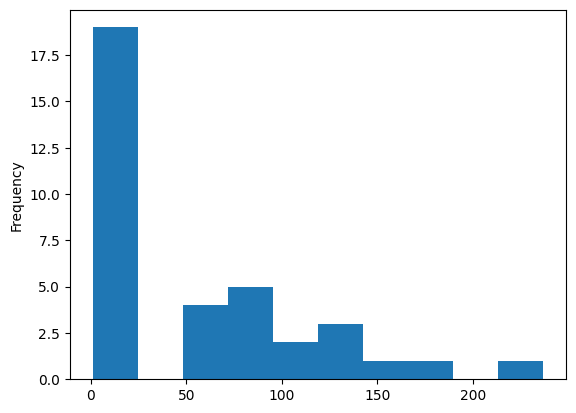

In [68]:
df_all_data_cleaned = df_all_data_cleaned.sort_values("time")

df_all_data_cleaned["gap"] = df_all_data_cleaned["time"].diff().dt.seconds > 600  # 10 min gap
df_all_data_cleaned["session_id"] = df_all_data_cleaned["gap"].cumsum()
session_lengths = df_all_data_cleaned.groupby("session_id").size()
session_lengths.plot(kind="hist")

<Axes: xlabel='hour', ylabel='day'>

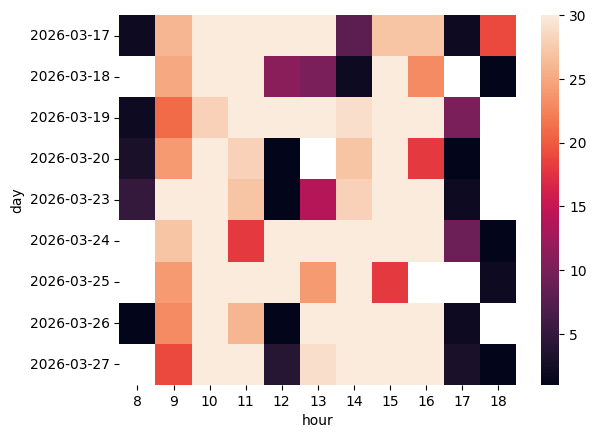

In [69]:
df_all_data_cleaned["hour"] = df_all_data_cleaned["time"].dt.hour
df_all_data_cleaned["day"] = df_all_data_cleaned["time"].dt.date

pivot = df_all_data_cleaned.pivot_table(index="day", columns="hour", aggfunc="size")

import seaborn as sns
sns.heatmap(pivot)